<img src="udc1.png" alt="UDC"/>

# Notebook pour la classification d'images(déchets) avec JEPA. 

In [1]:
import outils
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = outils.Load_data.load_object("dataset2.zip")

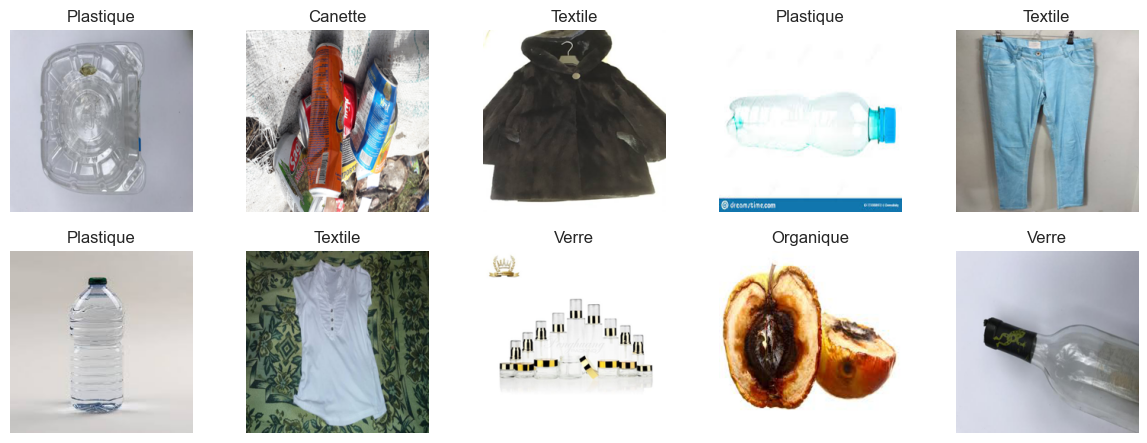

In [3]:
df.plot()

In [4]:
df.reshape(target_shape=(64, 64, 3))

Reshape en batch:   0%|          | 0/380 [00:00<?, ?it/s]

Reshape en batch: 100%|██████████| 380/380 [00:18<00:00, 20.44it/s]


In [5]:
df.encodage()

In [6]:
(X_train, y_train), (X_test, y_test) = df.create_data(test_size=0.2)

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [8]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.6, 1.4],
    channel_shift_range=30.0,
    fill_mode='nearest',
    rescale=1./255
)



test_datagen =  ImageDataGenerator(rescale= 1. / 255)

In [9]:
train_generator = train_datagen.flow(X_train,y_train,batch_size=32)
test_generator  = test_datagen.flow(X_test,y_test,batch_size=32)

In [15]:
from tensorflow import keras
from keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam,SGD,RMSprop
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.callbacks import LearningRateScheduler,ModelCheckpoint,ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Model, Input
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Dense, Dropout, Add, BatchNormalization, Input, Flatten
from tensorflow.keras.applications import InceptionResNetV2
from keras.saving import register_keras_serializable

In [11]:
# Dimensions
IMG_HEIGHT = 64
IMG_WIDTH = 64
IMG_CHANNELS = 3
EMBED_DIM = 128           # Dimension de l'espace latent
NUM_CLASSES = 5
BATCH_SIZE = 64
EPOCHS_JEPA = 100          # Pré-entraînement auto-supervisé
EPOCHS_CLASS = 50         # Classification supervisée
EMA_DECAY = 0.99          # Pour l'encodeur cible

In [16]:
@register_keras_serializable()
def build_encoder(embed_dim=EMBED_DIM, input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)):
    """
    Encodeur CNN basé sur l'architecture de l'utilisateur.
    Sortie : vecteur latent de dimension embed_dim.
    """
    inputs = tf.keras.Input(shape=input_shape, name='encoder_input')
    
    # Bloc 1: 64x64 → 32x32
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Bloc 2: 32x32 → 16x16
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Bloc 3: 16x16 → 8x8
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Bloc 4: 8x8 → 4x4
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Bloc 5: 4x4 → 2x2
    x = layers.Conv2D(132, (2, 2), activation='relu', padding='same', kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Aplatissement et projection
    x = layers.Flatten()(x)
    outputs = layers.Dense(embed_dim, activation='relu', name='latent')(x)
    
    return Model(inputs, outputs, name='encoder')

In [17]:
@register_keras_serializable()
def build_predictor(embed_dim=EMBED_DIM):
    """
    Prédicteur JEPA : prédit l'embedding cible à partir de l'embedding contextuel
    """
    inputs = tf.keras.Input(shape=(embed_dim,), name='predictor_input')
    x = layers.Dense(512, activation='relu', kernel_regularizer=l2(0.001))(inputs)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
    outputs = layers.Dense(embed_dim, name='prediction')(x)
    return Model(inputs, outputs, name='predictor')

In [18]:
@register_keras_serializable()
def build_classifier(embed_dim=EMBED_DIM, num_classes=NUM_CLASSES):
    """
    Tête de classification linéaire (pour linear probing)
    """
    inputs = tf.keras.Input(shape=(embed_dim,), name='classifier_input')
    x = layers.Dense(64, activation='relu', kernel_regularizer=l2(0.001))(inputs)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, name='logits')(x)
    return Model(inputs, outputs, name='classifier')

In [19]:
@register_keras_serializable()
class JEPA_Model(tf.keras.Model):
    """
    Modèle JEPA unifié avec support complet de sauvegarde/chargement
    """
    
    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES, **kwargs):
        super().__init__(**kwargs)
        
        self.embed_dim = embed_dim
        self.num_classes = num_classes
        
        # Construire les sous-modèles
        self.encoder = build_encoder(embed_dim)
        self.target_encoder = build_encoder(embed_dim)
        self.predictor = build_predictor(embed_dim)
        self.classifier = build_classifier(embed_dim, num_classes)
        
        # Initialiser l'encodeur cible
        self._init_target_encoder()
        
        # Métriques
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.acc_metric = tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")
        self.jepa_loss_tracker = tf.keras.metrics.Mean(name="jepa_loss")
        self.cls_loss_tracker = tf.keras.metrics.Mean(name="cls_loss")
    
    def _init_target_encoder(self):
        """Initialise l'encodeur cible avec les poids de l'encodeur source"""
        for w, tw in zip(self.encoder.weights, self.target_encoder.weights):
            tw.assign(w)
        self.target_encoder.trainable = False
    
    def _update_target_encoder(self, decay=EMA_DECAY):
        """Met à jour l'encodeur cible par EMA"""
        for w, tw in zip(self.encoder.weights, self.target_encoder.weights):
            tw.assign(decay * tw + (1 - decay) * w)
    
    def compute_loss(self, logits, anomaly_score, labels, lambda_cls=1.0, lambda_jepa=0.5):
        loss_cls = tf.reduce_mean(
            tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)
        )
        loss_jepa = tf.reduce_mean(anomaly_score)
        return lambda_cls * loss_cls + lambda_jepa * loss_jepa
    
    def call(self, x, training=False):
        # Encodage
        z = self.encoder(x, training=training)
        
        # Prédiction JEPA
        z_pred = self.predictor(z, training=training)
        
        # Encodage cible (stop_gradient)
        z_target = tf.stop_gradient(self.target_encoder(x, training=training))
        
        # Classification
        logits = self.classifier(z, training=training)
        
        # Score d'anomalie
        anomaly_score = tf.norm(z_pred - z_target, axis=1)
        
        return logits, anomaly_score
    
    def train_step(self, data):
        images, labels = data
        
        with tf.GradientTape() as tape:
            logits, anomaly_score = self(images, training=True)
            loss = self.compute_loss(logits, anomaly_score, labels)
        
        train_vars = self.trainable_variables
        grads = tape.gradient(loss, train_vars)
        self.optimizer.apply_gradients(zip(grads, train_vars))
        
        self._update_target_encoder()
        
        self.loss_tracker.update_state(loss)
        self.acc_metric.update_state(labels, logits)
        self.jepa_loss_tracker.update_state(tf.reduce_mean(anomaly_score))
        self.cls_loss_tracker.update_state(
            tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True))
        )
        
        return {
            "loss": self.loss_tracker.result(),
            "accuracy": self.acc_metric.result(),
            "jepa_loss": self.jepa_loss_tracker.result(),
            "cls_loss": self.cls_loss_tracker.result()
        }
    
    def test_step(self, data):
        images, labels = data
        logits, anomaly_score = self(images, training=False)
        loss = self.compute_loss(logits, anomaly_score, labels)
        
        self.loss_tracker.update_state(loss)
        self.acc_metric.update_state(labels, logits)
        self.jepa_loss_tracker.update_state(tf.reduce_mean(anomaly_score))
        self.cls_loss_tracker.update_state(
            tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True))
        )
        
        return {
            "loss": self.loss_tracker.result(),
            "accuracy": self.acc_metric.result(),
            "jepa_loss": self.jepa_loss_tracker.result(),
            "cls_loss": self.cls_loss_tracker.result()
        }
    
    @property
    def metrics(self):
        return [self.loss_tracker, self.acc_metric, self.jepa_loss_tracker, self.cls_loss_tracker]
    
    # ============================================
    # MÉTHODES POUR LA SAUVEGARDE/CHARGEMENT
    # ============================================
    
    def get_config(self):
        """Retourne la configuration pour la sauvegarde"""
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_classes": self.num_classes
        })
        return config
    
    @classmethod
    def from_config(cls, config):
        """Reconstruit le modèle à partir de la configuration"""
        return cls(**config)


In [20]:
model = JEPA_Model(embed_dim=128, num_classes=5)

In [21]:
model.summary()

Model: "jepa__model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ (None, 128)            │       378,196 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 128)            │       378,196 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictor (Functional)          │ (None, 128)            │       230,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Functional)         │ (None, 5)              │         8,581 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 995,245 (3.80 MB)

 Trainable params: 616,081 (2.35 MB)

 Non-trainable params: 379,164 (1.45 MB)

In [22]:
model.save("jepa_model.keras")

C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\keras\src\saving\saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


In [23]:
def load_model(filepath):
   
    custom_objects = {
        'JEPA_Model': JEPA_Model,
        'build_encoder': build_encoder,
        'build_predictor': build_predictor,
        'build_classifier': build_classifier
    }
    
   
    model = tf.keras.models.load_model(
        filepath,
        custom_objects=custom_objects,
        compile=False
    )
    
    return model


In [25]:
def format_time(seconds):
    """Convertit un temps en secondes en format jours:heures:minutes:secondes"""
    days = int(seconds // 86400)
    hours = int((seconds % 86400) // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    
    if days > 0:
        return f"{days}j {hours}h {minutes}m {secs}s"
    elif hours > 0:
        return f"{hours}h {minutes}m {secs}s"
    elif minutes > 0:
        return f"{minutes}m {secs}s"
    else:
        return f"{secs}s"

In [ ]:
import time

initial_learning_rate = 1e-4

# Callbacks avec modes explicites
param_surv_app1 = ModelCheckpoint(
    "model_jepa_cls_1.keras",
    monitor="val_accuracy",
    verbose=1,
    save_best_only=True,
    mode='max'
)

param_surv_app2 = EarlyStopping(
    monitor='val_loss',
    patience=30,
    verbose=1,
    restore_best_weights=True,
    mode='min'
)

param_surv_app3 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=10,
    verbose=1,
    mode='min'
)

# Compilation
model.compile(optimizer=RMSprop(learning_rate=initial_learning_rate))

# Entraînement
start_time = time.time()

historique = model.fit(
    train_generator,
    epochs=300,
    validation_data=test_generator,
    callbacks=[param_surv_app1, param_surv_app2, param_surv_app3]
)

end_time = time.time()
elapsed = end_time - start_time
print(f"Temps d'entraînement : {format_time(elapsed)}")


C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
607/607 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.4965 - cls_loss: 1.2585 - jepa_loss: 2.0451 - loss: 2.2811
Epoch 1: val_accuracy improved from None to 0.65239, saving model to model_jepa.keras
607/607 ━━━━━━━━━━━━━━━━━━━━ 98s 155ms/step - accuracy: 0.5429 - cls_loss: 1.1395 - jepa_loss: 2.5438 - loss: 2.4114 - val_accuracy: 0.6524 - val_cls_loss: 0.8916 - val_jepa_loss: 5.1567 - val_loss: 3.4700 - learning_rate: 1.0000e-04
Epoch 2/200
607/607 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.6169 - cls_loss: 0.9775 - jepa_loss: 6.1062 - loss: 4.0306
Epoch 2: val_accuracy improved from 0.65239 to 0.70428, saving model to model_jepa.keras
607/607 ━━━━━━━━━━━━━━━━━━━━ 86s 142ms/step - accuracy: 0.6268 - cls_loss: 0.9545 - jepa_loss: 6.6405 - loss: 4.2747 - val_accuracy: 0.7043 - val_cls_loss: 0.7799 - val_jepa_loss: 6.6104 - val_loss: 4.0851 - learning_rate: 1.0000e-04
Epoch 3/200
607/607 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.6530 - cls_loss: 0.8974 - jepa_l

In [39]:
historique

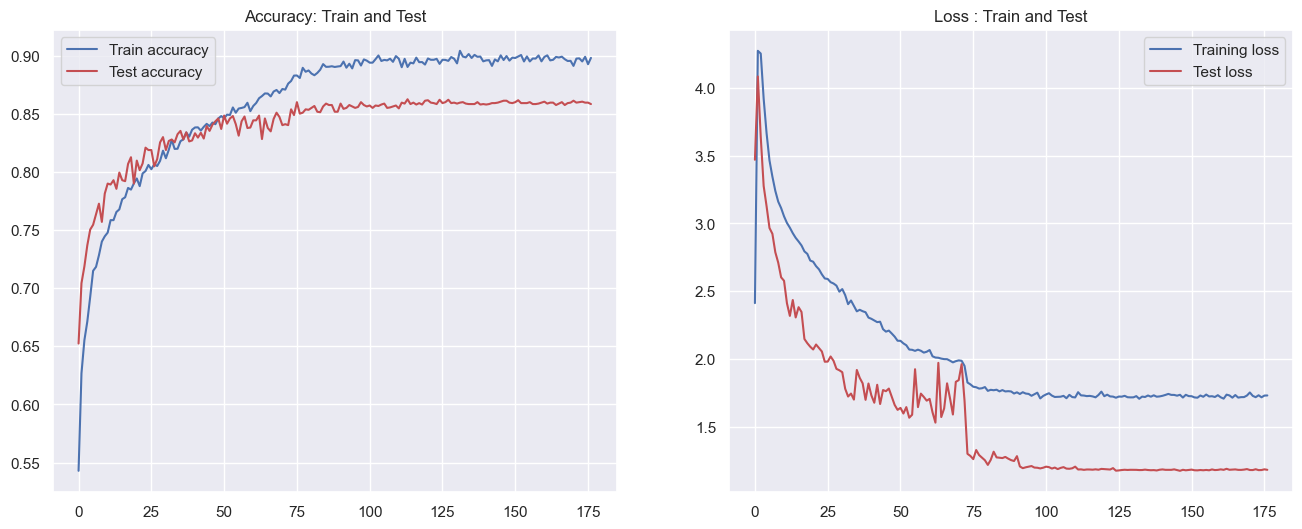

In [19]:
outils.plot_result(historique,name_fig="plot_cls_jepa_1",register_plot=False)

In [20]:

from sklearn.metrics import confusion_matrix,classification_report,f1_score
import seaborn as sns



def evaluation(model, X_test, y_test, return_conf_mat=True, return_clss=True, labels=[]):
    # Prédictions
    predict_proba = model.predict(X_test)
    y_pred = np.argmax(predict_proba[0], axis=1)

    # Matrice de confusion
    conf_matrice = confusion_matrix(y_test, y_pred)

    if return_conf_mat:
        print("========================================== Confusion Matrix =====================================================")
        print(conf_matrice)
        f, ax = plt.subplots(figsize=(6, 5))
        conf_matrice_nor = conf_matrice.astype('float') / conf_matrice.sum(axis=1)[:, np.newaxis]
        sns.heatmap(conf_matrice_nor, annot=True, fmt=".2%", linewidths=.5, ax=ax,
                    xticklabels=labels, yticklabels=labels, cbar=False)
        plt.ylabel("True class")
        plt.xlabel("Predicted class")
        plt.title("Normalized Confusion Matrix")
        plt.show()

    if return_clss:
        print("========================================= Detailed Metrics =====================================================")
        # Rapport complet (inclut précision, rappel et f1-score par classe)
        report = classification_report(y_test, y_pred, target_names=labels, digits=4)
        print(report)

        # F1 macro et weighted
        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')

        print(f"Macro F1-score (unweighted): {f1_macro:.4f}")
        print(f"Weighted F1-score: {f1_weighted:.4f}")
    return y_pred

In [21]:
X_test = X_test.astype('float32') / 255.0

In [50]:
y_result = model.predict(X_test)

76/76 ━━━━━━━━━━━━━━━━━━━━ 19s 252ms/step


76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step
========================================== Confusion Matrix =====================================================
[[290  10  25   5   9]
 [  9 419  17  24  13]
 [ 35  16 381  33  29]
 [  4   8  12 531   0]
 [ 26  17  42   3 470]]


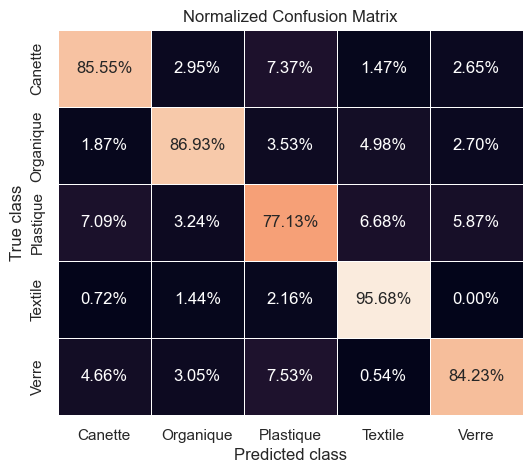

========================================= Detailed Metrics =====================================================
              precision    recall  f1-score   support

     Canette     0.7967    0.8555    0.8250       339
   Organique     0.8915    0.8693    0.8803       482
   Plastique     0.7987    0.7713    0.7848       494
     Textile     0.8909    0.9568    0.9227       555
       Verre     0.9021    0.8423    0.8712       558

    accuracy                         0.8612      2428
   macro avg     0.8560    0.8590    0.8568      2428
weighted avg     0.8617    0.8612    0.8607      2428

Macro F1-score (unweighted): 0.8568
Weighted F1-score: 0.8607


array([0, 4, 2, ..., 4, 3, 4], shape=(2428,))

In [22]:
evaluation(model=model, X_test=X_test, y_test=y_test, return_conf_mat=True, return_clss=True, labels=df.name_label_)

In [55]:
y_result[0].shape

(2428, 5)

In [23]:
X_test.shape

(2428, 64, 64, 3)

In [24]:
model_3 = load_model("model_jepa.keras")

TypeError: Could not locate class 'JEPA_Model'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'module': None, 'class_name': 'JEPA_Model', 'config': {'embed_dim': 128, 'num_classes': 5}, 'registered_name': 'JEPA_Model', 'build_config': {'input_shape': [None, 64, 64, 3]}, 'compile_config': {'optimizer': {'module': 'keras.optimizers', 'class_name': 'RMSprop', 'config': {'name': 'rmsprop', 'learning_rate': 3.999999989900971e-06, 'weight_decay': None, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'rho': 0.9, 'momentum': 0.0, 'epsilon': 1e-07, 'centered': False}, 'registered_name': None}, 'loss': None, 'loss_weights': None, 'metrics': None, 'weighted_metrics': None, 'run_eagerly': False, 'steps_per_execution': 1, 'jit_compile': False}}